In [28]:
""" 
This part is to build Multi layer perceptron
Building model:
Step 1: create dataset from word: given N length of characters -> predict the next characters
Step 2: create vocabs: 26 words + 1 special . character = 27 characters
Step 3: create Embedding layer with size (27, 2) -> Input: (Batch size, context length, embedding size) (32, 3, 2) -> (32, 6)
Step 4: create hidden layers: (6 -> 100) (100 -> 27)
Step 5: create cross entropy loss = exp -> normalise -> negative log likelihood
"""

' \nThis part is to build Multi layer perceptron\nBuilding model:\nStep 1: create dataset from word: given N length of characters -> predict the next characters\nStep 2: create vocabs: 26 words + 1 special . character = 27 characters\nStep 3: create Embedding layer with size (27, 2) -> Input: (Batch size, context length, embedding size) (32, 3, 2) -> (32, 6)\nStep 4: create hidden layers: (6 -> 100) (100 -> 27)\nStep 5: create cross entropy loss = exp -> normalise -> negative log likelihood\n'

In [29]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [30]:
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [31]:
len(words)

32033

In [32]:
chars = sorted(list(set("".join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}

In [33]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [34]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

In [35]:
def build_words(words):
    block_size = 3 # context length
    X, Y = [], []

    for word in words:
        context = [0] * block_size
        for ch in word + ".":
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            # print("".join(itos[i] for i in context), "--->", itos[idx])
            context = context[1:] + [idx]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

Xtr, Ytr = build_words(words[:n1])
Xval, Yval = build_words(words[n1:n2])
Xtest, Ytest = build_words(words[n2:])

In [36]:
print(Xtr.shape)
print(Xval.shape)
print(Xtest.shape)

torch.Size([182625, 3])
torch.Size([22655, 3])
torch.Size([22866, 3])


In [37]:
C = torch.rand((27, 2)) # embedding layer, 27 chars, size of embedding = 2

In [38]:
C[5]

tensor([0.1508, 0.3947])

In [39]:
F.one_hot(torch.tensor(5), 27).float() @ C

tensor([0.1508, 0.3947])

In [40]:
emb = C[X]

In [65]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 12), generator=g)
W1 = torch.rand((36, 400), generator=g)
b1 = torch.rand((400), generator=g)
W2 = torch.rand((400, 27), generator=g)
b2 = torch.rand((27), generator=g)
parameters = [C, W1, b1, W2, b2]

In [66]:
sum(p.nelement() for p in parameters)

25951

In [67]:
for p in parameters:
    p.requires_grad = True

In [68]:
lri = []
lossi = []
stepi = []

In [69]:
lr = 1e-3
batch_size = 128

for i in range(int(1e5)):
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    emb = C[Xtr[idx]] # batch size, 3, 2
    h = torch.tanh(emb.view(-1, 36) @ W1 + b1) # batch_size, 100
    logits = h @ W2 + b2 # batch_size, 27
    loss = F.cross_entropy(logits, Ytr[idx])

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 5e4 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    
    lossi.append(loss.item())
    stepi.append(i)


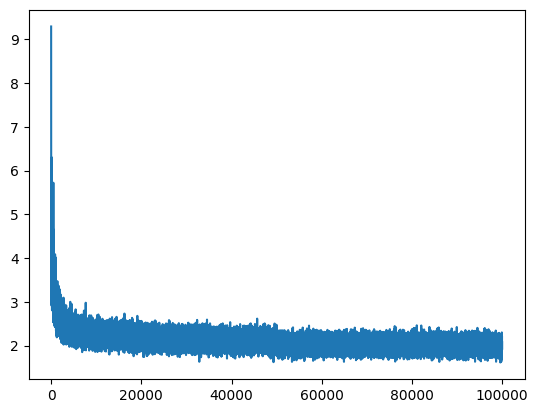

In [70]:
plt.plot(stepi, lossi)

In [71]:
emb = C[Xval]
h = torch.tanh(emb.view(-1, 36) @ W1 + b1)
logit = h @ W2 + b2
loss = F.cross_entropy(logit, Yval)

print(f"val loss: {loss}")

val loss: 2.093939781188965


In [ ]:
# predict
